In [1]:
import sys
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!unzip /content/drive/MyDrive/dataset_train.zip -d /content/dataset_train/

Archive:  /content/drive/MyDrive/dataset_train.zip
  inflating: /content/dataset_train/__MACOSX/._dataset_train  
  inflating: /content/dataset_train/dataset_train/.DS_Store  
  inflating: /content/dataset_train/__MACOSX/dataset_train/._.DS_Store  
  inflating: /content/dataset_train/__MACOSX/dataset_train/._real  
  inflating: /content/dataset_train/__MACOSX/dataset_train/._fake  
replace /content/dataset_train/dataset_train/real/14147.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/dataset_train/dataset_train/real/14147.jpg  
replace /content/dataset_train/__MACOSX/dataset_train/real/._14147.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [4]:
!unzip /content/drive/MyDrive/dataset_test.zip -d /content/dataset_test/

Archive:  /content/drive/MyDrive/dataset_test.zip
  inflating: /content/dataset_test/__MACOSX/._dataset_test  
  inflating: /content/dataset_test/dataset_test/.DS_Store  
  inflating: /content/dataset_test/__MACOSX/dataset_test/._.DS_Store  
  inflating: /content/dataset_test/__MACOSX/dataset_test/._real  
  inflating: /content/dataset_test/__MACOSX/dataset_test/._fake  
replace /content/dataset_test/dataset_test/real/19463.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [14]:
def load_image_dataset(data_path, batch_size=32, img_size=(200, 200), subset_ratio=1.0):
    """
    Load images from the specified directory.

    Expects structure:
       data_path/real/...
       data_path/fake/...

    Parameters:
        data_path (str): Path to dataset (e.g., "dataset_train" or "dataset_test").
        batch_size (int): Number of images per batch.
        img_size (tuple): Target image size.
        subset_ratio (float): Fraction of the dataset to use (default 1.0 = all).

    Returns:
        A tf.data.Dataset object ready for training/testing and the class names.
    """
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        data_path,
        labels='inferred',
        label_mode='binary',
        batch_size=batch_size,
        image_size=img_size,
        shuffle=True
    )
    class_names = dataset.class_names

    if subset_ratio < 1.0:
        total_batches = tf.data.experimental.cardinality(dataset).numpy()
        subset_batches = int(total_batches * subset_ratio)
        dataset = dataset.take(subset_batches)

    return dataset, class_names

In [15]:
import os
def clean_dataset(directory):
    allowed_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

    for root, dirs, files in os.walk(directory):
        for file in files:
            ext = os.path.splitext(file)[-1].lower()
            if ext not in allowed_extensions:
                file_path = os.path.join(root, file)
                print(f"Deleting non-image file: {file_path}")
                os.remove(file_path)

# Clean train and test folders
clean_dataset("/content/dataset_train")
clean_dataset("/content/dataset_test")

In [23]:
!rm -r /content/dataset_test/__MACOSX
!rm -r /content/dataset_train/__MACOSX

In [24]:
def scale_images_to_unit_range(dataset):
    """
    Applies scaling to images in the dataset so that their pixel values are in the [0, 1] range.
    """
    def scaling_fn(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    return dataset.map(scaling_fn)

In [25]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.plot(epochs_range, acc, 'b', label='Training accuracy')
    plt.plot(epochs_range, val_acc, 'r', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs_range, loss, 'b', label='Training loss')
    plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

In [29]:
batch_size = 32
img_size = (200,200)
img_width, img_height = img_size

train_data_path = "/content/dataset_train/dataset_train"
test_data_path = "/content/dataset_test/dataset_test"

In [30]:
train_dataset, class_names = load_image_dataset(
    train_data_path, batch_size=batch_size, img_size=img_size, subset_ratio=1.0
)
train_dataset = scale_images_to_unit_range(train_dataset)

test_dataset, _ = load_image_dataset(
    test_data_path, batch_size=batch_size, img_size=img_size, subset_ratio=1.0
)
test_dataset = scale_images_to_unit_range(test_dataset)

train_count = tf.data.experimental.cardinality(train_dataset).numpy()
test_count = tf.data.experimental.cardinality(test_dataset).numpy()

print(f"Number of training batches: {train_count}")
print(f"Number of validation batches: {test_count}\n")

print(f"Approximate number of training images: {train_count * batch_size}")
print(f"Approximate number of validation images: {test_count * batch_size}")

print(f"Class names: {class_names}")

Found 96767 files belonging to 2 classes.
Found 24192 files belonging to 2 classes.
Number of training batches: 3024
Number of validation batches: 756

Approximate number of training images: 96768
Approximate number of validation images: 24192
Class names: ['fake', 'real']


In [31]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_size[0], img_size[1], 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])


In [32]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 200, 200, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,849 (1.55 MB)

 Trainable params: 405,889 (1.55 MB)

 Non-trainable params: 960 (3.75 KB)

In [33]:
epochs = 5

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs,
    callbacks=[early_stopping]
)

Epoch 1/5
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 178s 55ms/step - accuracy: 0.7198 - loss: 0.5471 - val_accuracy: 0.7157 - val_loss: 0.5765
Epoch 2/5
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 163s 54ms/step - accuracy: 0.8408 - loss: 0.3690 - val_accuracy: 0.8523 - val_loss: 0.3357
Epoch 3/5
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 201s 54ms/step - accuracy: 0.8928 - loss: 0.2695 - val_accuracy: 0.8999 - val_loss: 0.2591
Epoch 4/5
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 194s 51ms/step - accuracy: 0.9226 - loss: 0.2039 - val_accuracy: 0.7669 - val_loss: 0.5579
Epoch 5/5
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 203s 51ms/step - accuracy: 0.9399 - loss: 0.1616 - val_accuracy: 0.8424 - val_loss: 0.3971


In [34]:
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

756/756 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8992 - loss: 0.2585
Test Loss: 0.2591, Test Accuracy: 0.8999


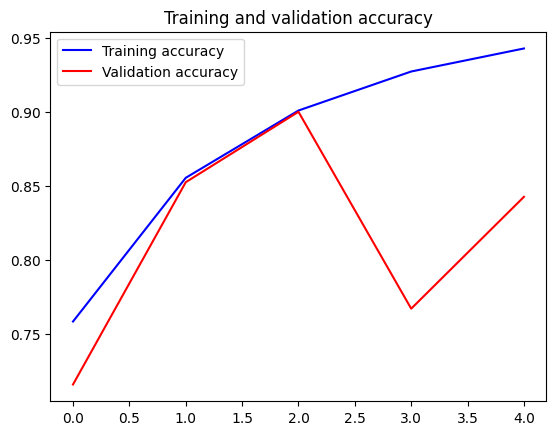

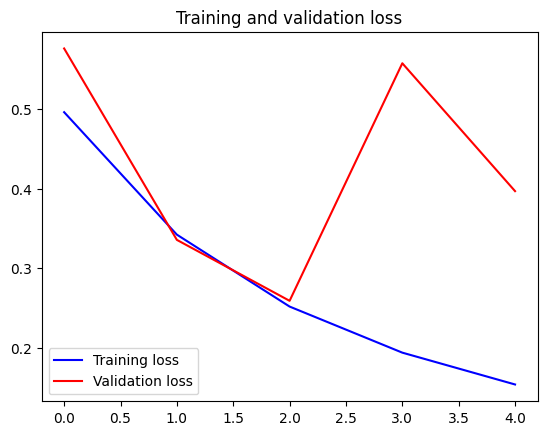

In [35]:
plot_history(history)

In [36]:
model.save('../weights/baseline_model.h5')